# 이탈 요인 정량화 (`02_Feature_Importance`)

```
05_Collinearity_Recheck → 03_Modeling/01_Baseline_Models → [03_Modeling/02_Feature_Importance] → 03_Final_Model_Tiers
```

## 목적

`01_Baseline_Models`에서 "얼마나 잘 맞히는가"를 정리했다. 이 노트북은 **"무엇이 25일 이후 이탈을 가르는가"**를 정량화한다.
P5 해석·개입 전략의 근거이자, **최종 모델 결정의 세 번째 기준(해석 일관성)**을 만든다.

| 질문 | 지표 | 절 |
|---|---|---|
| 이 요소를 없애면(섞으면) 예측이 얼마나 나빠지나 | Permutation importance (PR-AUC 하락) | 3 |
| 세 모델이 같은 요소를 중요하게 보나 | 모델 간 순위 상관, 상위 요소 겹침, 구조 의존도 | 4 |
| 과목마다 중요한 요소가 다른가 | 과목 내 permutation importance | 5 |
| 요소가 어느 방향으로 얼마나 영향을 주나 | Logistic 오즈비(95% 신뢰구간) | 6 |
| 영향이 어떤 모양인가(임계점·꺾임) | XGBoost SHAP | 7 |
| 바꿀 수 있는 요소인가 | 개입 가능성 분류 | 8 |

## 원칙

- **개발 세트(2013B·2013J·2014B)만 쓴다.** holdout(2014J)은 건드리지 않는다. 최종 모델을 이 결과로 정하더라도 holdout 재사용이 되지 않게 하기 위함이다.
- **01과 같은 분할·파라미터·피처를 쓰고, 01의 OOF 예측이 똑같이 재현되는지 먼저 확인한다**(2절).
- **중요도는 인과가 아니다.** "미제출이 이탈을 부른다"가 아니라 "미제출이 이탈을 잘 예측한다"는 뜻이다.
- **서로 겹치는 피처는 중요도가 나눠진다.** 클릭 수·활동일·자원 수(상관 0.66–0.74)처럼 묶인 피처는 **그룹 단위**로도 본다.
- **성별은 과목을 통제한 상태로만 해석한다**(`03_Landmark25_EDA` 10절 심슨의 역설).

선행: `Notebooks/03_Modeling/01_Baseline_Models.ipynb`, `CSV_files/모델링/champion_summary_n25.json`

## 1. 환경 설정과 데이터 로드

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xgboost
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.facecolor': SURFACE,
                     'axes.facecolor': SURFACE, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRID, 'text.color': INK_2, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False})
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
N_JOBS = 4          # 01과 같은 메모리 제한
N_REPEATS = 5       # permutation 반복 횟수
MODEL_COLORS = {'Logistic': '#2a78d6', 'RandomForest': '#eb6834', 'XGBoost': '#1baf7a'}
LEARNERS = ['Logistic', 'RandomForest', 'XGBoost']
DIV = LinearSegmentedColormap.from_list('div', ['#1c5cab', '#86b6ef', '#f0efec', '#f0a47f', '#c2461a'])


def show(frame, formats=None):
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
DATA_DIR = PROJECT_ROOT / 'CSV_files' / '통합 버전'
MODEL_DIR = PROJECT_ROOT / 'CSV_files' / '모델링'

spec = json.load(open(DATA_DIR / 'feature_spec_n25.json', encoding='utf-8'))
summary = json.load(open(MODEL_DIR / 'champion_summary_n25.json', encoding='utf-8'))
saved_oof = pd.read_csv(MODEL_DIR / 'dev_oof_predictions_n25.csv')
df = pd.read_csv(DATA_DIR / 'model_df_clean_n25.csv')

TARGET, GROUP_COL, HOLDOUT_KEY = spec['target'], spec['group_col'], spec['holdout_key']
NUM, CAT = spec['numeric_features'], spec['categorical_features']
FEATURES = NUM + CAT
GRAIN = ['id_student', 'code_module', 'code_presentation']
BEST_PARAMS = summary['best_params']

assert summary['features_in_order'] == FEATURES, '01 모델링에서 쓴 피처와 명세가 다름'
assert not summary['relative_features']['adopted']

df['presentation_period'] = df['code_presentation'].str[-1]
df[TARGET] = df[TARGET].astype(int)
dev = df[df[HOLDOUT_KEY] != summary['holdout']['term']].reset_index(drop=True)
X, y, groups = dev[FEATURES], dev[TARGET], dev[GROUP_COL]
assert len(dev) == summary['cv']['n_dev']
print(f'개발 세트 {len(dev):,}행 / 양성 {y.sum():,} / 피처 {len(FEATURES)}개 / holdout 미사용')
print('최적 파라미터:', BEST_PARAMS)

개발 세트 18,504행 / 양성 3,526 / 피처 20개 / holdout 미사용
최적 파라미터: {'Dummy': {}, 'Logistic': {'model__C': 100.0}, 'RandomForest': {'model__max_depth': 12, 'model__max_features': 0.5, 'model__min_samples_leaf': 30}, 'XGBoost': {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 30}}


## 2. 01 모델링 재현 확인

**왜 하는가**: 중요도는 "01에서 평가한 바로 그 모델"을 설명해야 의미가 있다. 01과 같은 분할(`StratifiedGroupKFold(5, shuffle=True, random_state=42)`,
`groups=id_student`)·파이프라인·최적 파라미터로 fold별 모델을 다시 학습하고, **OOF 예측이 01에 저장된 값과 일치하는지** 확인한다.
여기서 학습한 fold별 모델을 3·5절 permutation에 그대로 쓴다(검증 fold로만 평가하므로 학습 데이터로 중요도를 재는 낙관 편향이 없다).

In [2]:
def make_pipeline(name):
    # 01_Baseline_Models 4절과 동일한 정의
    if name == 'Logistic':
        prep = ColumnTransformer([
            ('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)), ('scale', RobustScaler())]), NUM),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT),
        ])
        model = LogisticRegression(class_weight='balanced', max_iter=5000)
    elif name == 'RandomForest':
        prep = ColumnTransformer([
            ('num', SimpleImputer(strategy='median', add_indicator=True), NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CAT),
        ])
        model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS)
    else:
        prep = ColumnTransformer([
            ('num', 'passthrough', NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT),
        ], sparse_threshold=0)
        model = XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=(y == 0).sum() / (y == 1).sum(), tree_method='hist',
                              eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=N_JOBS)
    return Pipeline([('prep', prep), ('model', model)]).set_params(**BEST_PARAMS[name])


CV_SPLITS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(dev, y, groups=groups))
assert (saved_oof[GRAIN].to_numpy() == dev[GRAIN].to_numpy()).all(), '행 순서가 01과 다름'

fold_models = {n: [] for n in LEARNERS}
oof = {n: np.zeros(len(dev)) for n in LEARNERS}
for name in LEARNERS:
    t0 = time.perf_counter()
    for tr, va in CV_SPLITS:
        pipe = make_pipeline(name).fit(X.iloc[tr], y.iloc[tr])
        fold_models[name].append(pipe)
        oof[name][va] = pipe.predict_proba(X.iloc[va])[:, 1]
    diff = np.abs(oof[name] - saved_oof[f'oof_{name}'].to_numpy()).max()
    print(f'{name:<12} 재학습 {time.perf_counter() - t0:5.1f}s | 01 저장 OOF와 최대 차이 {diff:.2e}')
    assert diff < 1e-6, f'{name} OOF가 01과 일치하지 않음'

base = pd.DataFrame({n: [average_precision_score(y.iloc[va], oof[n][va]) for _, va in CV_SPLITS] for n in LEARNERS})
base.index.name = 'fold'
show(base.T.assign(평균=base.mean()), {c: '{:.4f}' for c in list(base.index) + ['평균']})
print('01 기록 CV PR-AUC:', {n: round(v, 4) for n, v in summary['cv']['pr_auc_mean'].items()})

Logistic     재학습   3.4s | 01 저장 OOF와 최대 차이 1.11e-16


RandomForest 재학습  23.2s | 01 저장 OOF와 최대 차이 4.44e-16


XGBoost      재학습   9.7s | 01 저장 OOF와 최대 차이 9.71e-17


fold,0,1,2,3,4,평균
Logistic,0.3743,0.4010,0.4189,0.3993,0.4083,0.4004
RandomForest,0.3843,0.4022,0.4139,0.4303,0.4000,0.4061
XGBoost,0.3810,0.4060,0.4126,0.4178,0.4105,0.4055


01 기록 CV PR-AUC: {'Logistic': 0.4004, 'RandomForest': 0.4061, 'XGBoost': 0.4055}


## 3. 전역 Permutation Importance

**방법**

- 각 fold의 검증 데이터에서 **한 요소의 값만 무작위로 섞은 뒤** 같은 모델로 다시 예측해 PR-AUC가 얼마나 떨어지는지 잰다(`N_REPEATS = 5`회 반복 평균).
- 5개 fold 평균과 표준편차를 보고한다. 표준편차가 크면 그 요소의 중요도가 데이터 구성에 따라 흔들린다는 뜻이다.
- **개별 피처 20개**와 **의미 묶음 7개**를 모두 잰다. 묶음은 같은 행 순서로 함께 섞어 묶음 안의 관계를 보존한다.
  서로 겹치는 피처는 하나만 섞으면 다른 피처가 정보를 대신 전달해 중요도가 작게 나오므로, 묶음 결과가 "그 정보 전체의 가치"에 가깝다.

| 묶음 | 피처 |
|---|---|
| VLE 활동량 | `total_click_25`, `active_days_25`, `distinct_resources_25`, `no_vle_activity_25` |
| 평가 제출 | `n_opportunity_25`, `n_submitted_25` |
| 평가 점수·제출 시점 | `avg_score_25`, `avg_submit_delay_25` |
| 재수강 이력 | `num_of_prev_attempts`, `n_banked_25` |
| 수강 부담·등록 | `studied_credits`, `date_registration` |
| 인구통계·사회경제 | `gender`, `region`, `highest_education`, `imd_band`, `age_band`, `disability` |
| 과목·개강 시기 | `code_module`, `presentation_period` |

같은 루프에서 두 가지 변형도 함께 계산한다.

- **과목 안에서만 섞기**(묶음): 5절 과목별 중요도와 4절 "과목 간 차이 의존도"에 쓴다.
- **제출자 안에서만 값 섞기**(`avg_score_25`, `avg_submit_delay_25`, 평가 점수·제출 시점 묶음): 미제출자는 두 값이 결측이라, 전체를 섞으면
  **결측 위치(=제출 여부)까지 함께 섞인다.** 결측 위치는 그대로 두고 제출자끼리 값만 섞으면 **"점수·시점 값 자체"의 기여**만 남는다.
  전체 섞기와의 차이가 **"제출했는가"라는 정보의 기여**다(3.1절).

In [3]:
GROUPS = {
    'VLE 활동량': ['total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25'],
    '평가 제출': ['n_opportunity_25', 'n_submitted_25'],
    '평가 점수·제출 시점': ['avg_score_25', 'avg_submit_delay_25'],
    '재수강 이력': ['num_of_prev_attempts', 'n_banked_25'],
    '수강 부담·등록': ['studied_credits', 'date_registration'],
    '인구통계·사회경제': ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability'],
    '과목·개강 시기': ['code_module', 'presentation_period'],
}
assert sorted(sum(GROUPS.values(), [])) == sorted(FEATURES), '묶음이 피처를 빠짐없이 한 번씩 포함해야 함'
FEATURE_GROUP = {f: g for g, fs in GROUPS.items() for f in fs}
UNITS = [('feature', f, [f]) for f in FEATURES] + [('group', g, fs) for g, fs in GROUPS.items()]
MODULES = sorted(dev['code_module'].unique())
VALUE_ONLY_UNITS = {'avg_score_25', 'avg_submit_delay_25', '평가 점수·제출 시점'}

rng = np.random.default_rng(RANDOM_STATE)
rows = []
t0 = time.perf_counter()
for name in LEARNERS:
    for k, (tr, va) in enumerate(CV_SPLITS):
        model = fold_models[name][k]
        Xva, yva = X.iloc[va].reset_index(drop=True), y.iloc[va].to_numpy()
        mod_va = Xva['code_module'].to_numpy()
        mod_pos = {m: np.where(mod_va == m)[0] for m in MODULES}
        mod_ok = {m: len(p) > 0 and len(np.unique(yva[p])) == 2 for m, p in mod_pos.items()}
        p0 = oof[name][va]
        base_all = average_precision_score(yva, p0)
        base_mod = {m: average_precision_score(yva[p], p0[p]) for m, p in mod_pos.items() if mod_ok[m]}
        for kind, unit, cols in UNITS:
            for r in range(N_REPEATS):
                # (a) 전역 섞기
                order = rng.permutation(len(Xva))
                Xp = Xva.copy()
                for c in cols:
                    Xp[c] = Xva[c].to_numpy()[order]
                pp = model.predict_proba(Xp)[:, 1]
                rows.append({'model': name, 'fold': k, 'kind': kind, 'unit': unit, 'repeat': r, 'scope': 'global',
                             'module': 'ALL', 'drop': base_all - average_precision_score(yva, pp)})
                # (b) 과목 안에서만 섞기 — 묶음 단위만
                if kind == 'group':
                    order = np.arange(len(Xva))
                    for m, p in mod_pos.items():
                        order[p] = p[rng.permutation(len(p))]
                    Xp = Xva.copy()
                    for c in cols:
                        Xp[c] = Xva[c].to_numpy()[order]
                    pp = model.predict_proba(Xp)[:, 1]
                    rows.append({'model': name, 'fold': k, 'kind': kind, 'unit': unit, 'repeat': r, 'scope': 'within_module',
                                 'module': 'ALL', 'drop': base_all - average_precision_score(yva, pp)})
                    for m, p in mod_pos.items():
                        if mod_ok[m]:
                            rows.append({'model': name, 'fold': k, 'kind': kind, 'unit': unit, 'repeat': r, 'scope': 'within_module',
                                         'module': m, 'drop': base_mod[m] - average_precision_score(yva[p], pp[p])})
                # (c) 제출자 안에서만 값 섞기 — 결측(미제출) 위치는 그대로 두고 값만 섞는다
                if unit in VALUE_ONLY_UNITS:
                    keep = np.ones(len(Xva), dtype=bool)
                    for c in cols:
                        keep &= Xva[c].notna().to_numpy()
                    idx = np.where(keep)[0]
                    order = np.arange(len(Xva))
                    order[idx] = idx[rng.permutation(len(idx))]
                    Xp = Xva.copy()
                    for c in cols:
                        Xp[c] = Xva[c].to_numpy()[order]
                    pp = model.predict_proba(Xp)[:, 1]
                    rows.append({'model': name, 'fold': k, 'kind': kind, 'unit': unit, 'repeat': r, 'scope': 'value_only',
                                 'module': 'ALL', 'drop': base_all - average_precision_score(yva, pp)})
    print(f'{name} 완료 ({time.perf_counter() - t0:.0f}s 누적)')

perm = pd.DataFrame(rows)
fold_mean = perm.groupby(['model', 'kind', 'unit', 'scope', 'module', 'fold'])['drop'].mean().reset_index()
agg = fold_mean.groupby(['model', 'kind', 'unit', 'scope', 'module'])['drop'].agg(['mean', 'std']).reset_index()
print('permutation 결과 행:', len(perm))

Logistic 완료 (31s 누적)


RandomForest 완료 (223s 누적)


XGBoost 완료 (284s 누적)
permutation 결과 행: 6450


묶음별 PR-AUC 하락 (5-fold 평균, 비중 = 양수 하락의 합 대비)


model,Logistic,RandomForest,XGBoost,Logistic ±,Logistic 비중,RandomForest ±,RandomForest 비중,XGBoost ±,XGBoost 비중
unit,,,,,,,,,
평가 점수·제출 시점,0.0942,0.1467,0.1552,0.0173,35%,0.0110,53%,0.0140,56%
과목·개강 시기,0.1050,0.0509,0.0437,0.0147,39%,0.0078,18%,0.0080,16%
평가 제출,0.0230,0.0280,0.0374,0.0082,8%,0.0074,10%,0.0039,13%
수강 부담·등록,0.0156,0.0203,0.0201,0.0014,6%,0.0036,7%,0.0033,7%
인구통계·사회경제,0.0233,0.0117,0.0153,0.0068,9%,0.0023,4%,0.0046,5%
VLE 활동량,0.0037,0.0166,0.0071,0.0036,1%,0.0059,6%,0.0033,3%
재수강 이력,0.0072,0.0020,0.0008,0.0031,3%,0.0025,1%,0.0013,0%


하락                          표준편차                            순위                                묶음
model                 Logistic RandomForest XGBoost Logistic RandomForest XGBoost Logistic RandomForest XGBoost             
unit                                                                                                                        
avg_score_25            0.1749       0.1204  0.1223   0.0168       0.0121  0.0095        1            1       1  평가 점수·제출 시점
code_module             0.0998       0.0439  0.0352   0.0111       0.0095  0.0058        2            2       3     과목·개강 시기
avg_submit_delay_25     0.0855       0.0129  0.0092   0.0187       0.0038  0.0028        3            5       5  평가 점수·제출 시점
n_opportunity_25        0.0035       0.0255  0.0415   0.0022       0.0031  0.0058        9            3       2        평가 제출
studied_credits         0.0143       0.0136  0.0156   0.0039       0.0035  0.0030        5            4       4     수강 부담·등록
n_submitted_25          0.0283       0.0070  0.0008   0.0074       0.0063  0.0008        4            6      13        평가 제출
disability              0.0090       0.0053  0.0078   0.0036       0.0018  0.0037        6           10       6    인구통계·사회경제
highest_education       0.0064       0.0042  0.0028   0.0043       0.0015  0.0025        7           11      10    인구통계·사회경제
presentation_period     0.0022       0.0062  0.0046   0.0016       0.0034  0.0021       12            8       7     과목·개강 시기
date_registration       0.0020       0.0055  0.0039   0.0015       0.0037  0.0016       14            9       8     수강 부담·등록
gender                  0.0046       0.0026  0.0031   0.0013       0.0014  0.0011        8           12       9    인구통계·사회경제
total_click_25          0.0000       0.0066  0.0016   0.0004       0.0036  0.0011       18            7      11      VLE 활동량
num_of_prev_attempts    0.0035       0.0024  0.0005   0.0011       0.0023  0.0015       10           13      15       재수강 이력
active_days_25          0.0021       0.0021  0.0013   0.0025       0.0023  0.0011       13           15      12      VLE 활동량
distinct_resources_25  -0.0003       0.0023  0.0006   0.0009       0.0027  0.0017       20           14      14      VLE 활동량
n_banked_25             0.0022       0.0001 -0.0000   0.0016       0.0001  0.0001       11           18      19       재수강 이력
region                  0.0003       0.0011  0.0004   0.0020       0.0017  0.0009       17           16      16    인구통계·사회경제
age_band                0.0005       0.0003 -0.0000   0.0014       0.0005  0.0004       16           17      18    인구통계·사회경제
imd_band                0.0009      -0.0001 -0.0004   0.0016       0.0006  0.0005       15           20      20    인구통계·사회경제
no_vle_activity_25     -0.0002       0.0001  0.0000   0.0002       0.0002  0.0000       19           19      17      VLE 활동량

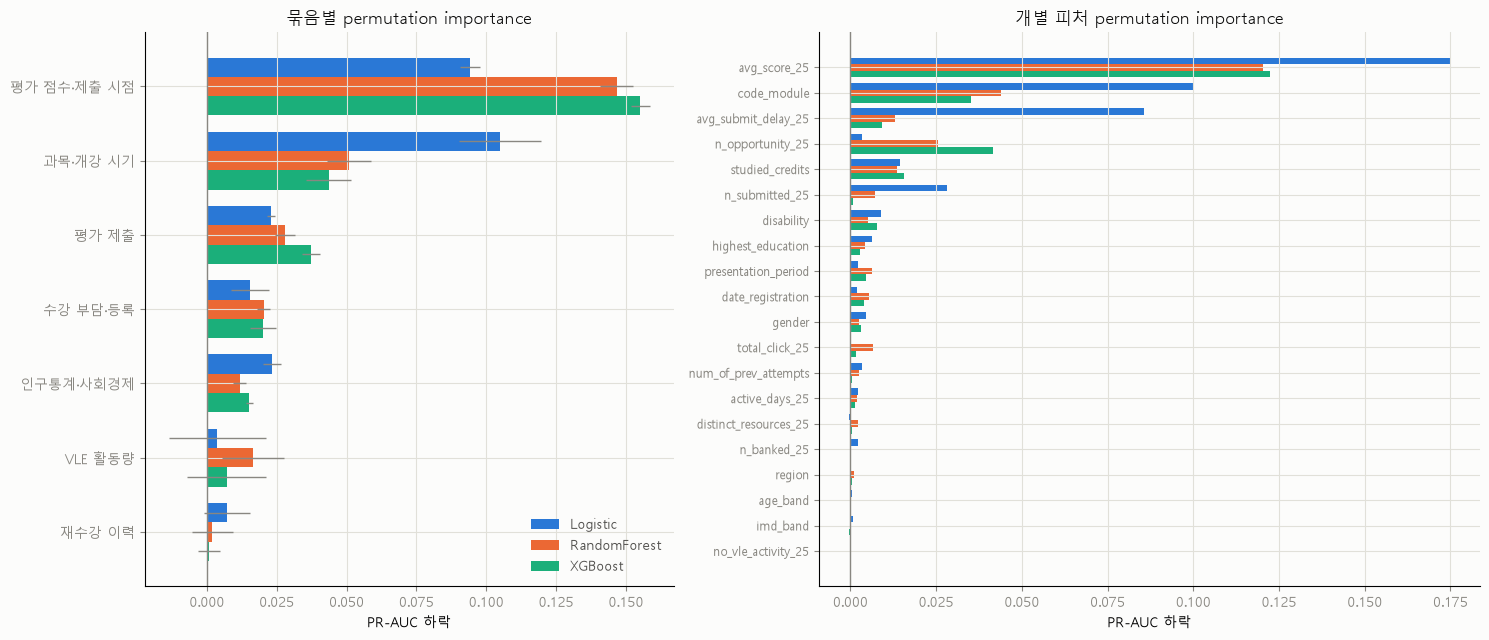

In [4]:
g_imp = agg[(agg.kind == 'group') & (agg.scope == 'global')].pivot(index='unit', columns='model', values='mean')[LEARNERS]
g_std = agg[(agg.kind == 'group') & (agg.scope == 'global')].pivot(index='unit', columns='model', values='std')[LEARNERS]
g_imp = g_imp.loc[g_imp.mean(axis=1).sort_values(ascending=False).index]
group_table = g_imp.copy()
for n in LEARNERS:
    group_table[f'{n} ±'] = g_std[n]
    group_table[f'{n} 비중'] = g_imp[n].clip(lower=0) / g_imp[n].clip(lower=0).sum()
print('묶음별 PR-AUC 하락 (5-fold 평균, 비중 = 양수 하락의 합 대비)')
show(group_table, {c: '{:.4f}' for c in LEARNERS + [f'{n} ±' for n in LEARNERS]} | {f'{n} 비중': '{:.0%}' for n in LEARNERS})

f_imp = agg[(agg.kind == 'feature') & (agg.scope == 'global')].pivot(index='unit', columns='model', values='mean')[LEARNERS]
f_std = agg[(agg.kind == 'feature') & (agg.scope == 'global')].pivot(index='unit', columns='model', values='std')[LEARNERS]
f_rank = f_imp.rank(ascending=False).astype(int)
feature_table = pd.concat({'하락': f_imp, '표준편차': f_std, '순위': f_rank}, axis=1)
feature_table[('묶음', '')] = [FEATURE_GROUP[f] for f in feature_table.index]
feature_table = feature_table.loc[f_imp.mean(axis=1).sort_values(ascending=False).index]
display(feature_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [1, 1.25]})
yy = np.arange(len(g_imp))
w = 0.26
for k, n in enumerate(LEARNERS):
    axes[0].barh(yy + (k - 1) * w, g_imp[n], xerr=g_std[n], height=w, color=MODEL_COLORS[n], label=n, error_kw={'elinewidth': 1, 'ecolor': MUTED})
axes[0].set_yticks(yy, g_imp.index)
axes[0].invert_yaxis()
axes[0].axvline(0, color=MUTED, lw=1)
axes[0].set(xlabel='PR-AUC 하락', title='묶음별 permutation importance')
axes[0].legend()
order = f_imp.mean(axis=1).sort_values(ascending=False).index
yy = np.arange(len(order))
for k, n in enumerate(LEARNERS):
    axes[1].barh(yy + (k - 1) * w, f_imp.loc[order, n], height=w, color=MODEL_COLORS[n], label=n)
axes[1].set_yticks(yy, order, fontsize=8.5)
axes[1].invert_yaxis()
axes[1].axvline(0, color=MUTED, lw=1)
axes[1].set(xlabel='PR-AUC 하락', title='개별 피처 permutation importance')
plt.tight_layout()
plt.show()

### 3.1 점수 수준 vs 제출 여부 분해

`avg_score_25`가 1위지만, 이 피처에는 **"점수가 몇 점인가"**와 **"애초에 제출했는가(결측 여부)"** 두 정보가 섞여 있다.
개입 관점에서 둘은 다르다. 제출은 알림으로 바꿀 수 있는 행동이고, 점수 수준은 학업 지원으로 간접적으로만 바뀐다.

In [5]:
vo = agg[(agg.scope == 'value_only')].pivot(index='unit', columns='model', values='mean')[LEARNERS]
full = agg[(agg.scope == 'global') & agg.unit.isin(VALUE_ONLY_UNITS)].pivot(index='unit', columns='model', values='mean')[LEARNERS]
decomp = pd.concat({'전체 섞기': full, '제출자 안 값만 섞기': vo, '제출 여부 몫(차이)': full - vo}, axis=1)
decomp = decomp.reindex(['평가 점수·제출 시점', 'avg_score_25', 'avg_submit_delay_25'])
display(decomp.round(4))
share = ((full - vo) / full).reindex(decomp.index)
print('전체 중요도 중 "제출 여부" 몫의 비율:')
display(share.round(2))

전체 섞기                      제출자 안 값만 섞기                      제출 여부 몫(차이)                     
model               Logistic RandomForest XGBoost    Logistic RandomForest XGBoost    Logistic RandomForest XGBoost
unit                                                                                                               
평가 점수·제출 시점           0.0942       0.1467  0.1552      0.0758       0.0971  0.0984      0.0183       0.0497  0.0568
avg_score_25          0.1749       0.1204  0.1223      0.0682       0.0831  0.0784      0.1066       0.0374  0.0439
avg_submit_delay_25   0.0855       0.0129  0.0092      0.0033       0.0057  0.0039      0.0823       0.0073  0.0053

전체 중요도 중 "제출 여부" 몫의 비율:


model,Logistic,RandomForest,XGBoost
unit,,,
평가 점수·제출 시점,0.19,0.34,0.37
avg_score_25,0.61,0.31,0.36
avg_submit_delay_25,0.96,0.56,0.57


**해석**

- **세 모델 모두 "25일까지 평가를 냈는가, 몇 점이었는가, 마감 전에 냈는가"를 가장 크게 본다.**
  - "평가 점수·제출 시점" 묶음 하락: Logistic 0.094 / RandomForest 0.147 / XGBoost 0.155. 트리 모델에서는 전체 하락의 53–56%다.
  - 개별 피처 1위는 세 모델 모두 `avg_score_25`(PR-AUC 하락 0.12–0.17)다.
- **Logistic만 "과목·개강 시기"가 1위 묶음이다**(0.105, 39%). 선형 모델은 과목 × 행동 상호작용을 배우지 못해 과목별 기준 이탈률 차이에 더 기댄다(4절).
- **수강 학점(`studied_credits`)은 세 모델 모두 4–5위**로 일관된 신호다.
- **VLE 활동량 묶음은 작다**(0.004–0.017). 평가 정보가 있으면 활동량 정보는 대부분 대체된다. 단 평가가 없는 EEE에서는 1위다(5절).
- **인구통계·사회경제에서는 장애 여부만 의미 있게 크고**(6–10위), 지역·IMD·나이는 PR-AUC 하락이 0에 가깝다.
- **`n_submitted_25`가 XGBoost에서 13위로 낮은 이유**: XGBoost는 `avg_score_25`의 결측(=미제출)을 직접 분기에 쓰므로 제출 여부 정보가 점수 피처에 흡수된다(3.1절).

**3.1 분해 — 점수 수준 vs 제출 여부**

| 모델 | 점수·시점 묶음 중 "제출 여부" 몫 | `avg_score_25` 중 몫 | `avg_submit_delay_25` 중 몫 |
|---|---:|---:|---:|
| Logistic | 19% | 61% | 96% |
| RandomForest | 34% | 31% | 56% |
| XGBoost | 37% | 36% | 57% |

- 트리 모델 기준으로 **점수·시점 신호의 약 1/3은 "제출했는가", 약 2/3는 "점수 수준·제출 시점 값 자체"**다.
- Logistic은 `avg_submit_delay_25` 중요도의 96%가 제출 여부다. 선형 모델은 제출 시점 값보다 결측 표시(미제출)를 주로 읽는다.
- 개입 관점: **제출 독려(행동)와 점수가 낮은 학생 지원(학업) 둘 다 필요하다**. 두 신호의 크기는 대략 1 : 2다.

## 4. 모델 간 일치도와 구조 의존도

**왜 보는가**: 최종 모델 결정의 세 번째 기준(해석 일관성)이다.

- **순위 상관(Spearman)**: 개별 피처 20개 중요도 순위가 모델끼리 얼마나 같은가. 높으면 어떤 모델을 골라도 "이탈을 가르는 요소" 설명이 같다.
- **상위 5개 겹침**: 실제로 보고서에 쓸 상위 요인이 같은가.
- **fold 간 순위 안정성**: 같은 모델 안에서 fold가 바뀌어도 중요도 순위가 유지되는가(fold별 순위 상관의 평균).
- **구조 의존도**: 전체 묶음 하락 중 "과목·개강 시기" 묶음이 차지하는 비중. 높을수록 학생 행동보다 **과목 기준 이탈률 차이에 기대는** 모델이다.
  01 학기 단위 검증과 12절 holdout에서 과목별 기준 이탈률 이동(GGG)이 약점이었으므로, 구조 의존도가 높은 모델은 학기 이동에 더 취약할 수 있다.
- **과목 간 차이 의존도**: 묶음을 과목 안에서만 섞었을 때 **사라지는 중요도**의 비중. `code_module`뿐 아니라 `n_opportunity_25`처럼
  **과목 일정을 대신 전달하는 피처**까지 포함해 "과목 간 차이에 기대는 정도"를 잰다. 구조 의존도보다 넓은 정의다.

In [6]:
rho = pd.DataFrame(index=LEARNERS, columns=LEARNERS, dtype=float)
top5 = {n: set(f_imp[n].sort_values(ascending=False).index[:5]) for n in LEARNERS}
for a in LEARNERS:
    for b in LEARNERS:
        rho.loc[a, b] = spearmanr(f_imp[a], f_imp[b]).statistic
print('개별 피처 중요도 순위 상관 (Spearman)')
display(rho.round(3))
print('상위 5개:')
for n in LEARNERS:
    print(f'  {n:<12}', sorted(top5[n], key=lambda f: -f_imp.loc[f, n]))
print('세 모델 공통 상위 5개:', sorted(set.intersection(*top5.values())))

within_g = agg[(agg.kind == 'group') & (agg.scope == 'within_module') & (agg.module == 'ALL')].pivot(index='unit', columns='model', values='mean')[LEARNERS].reindex(g_imp.index)
fold_f = fold_mean[(fold_mean.kind == 'feature') & (fold_mean.scope == 'global')]
stab_rows = []
for n in LEARNERS:
    mat = fold_f[fold_f.model == n].pivot(index='unit', columns='fold', values='drop')
    cors = [spearmanr(mat[i], mat[j]).statistic for i in mat.columns for j in mat.columns if i < j]
    pos = g_imp[n].clip(lower=0)
    stab_rows.append({'model': n, 'fold 간 순위 상관 평균': np.mean(cors), 'fold 간 순위 상관 최소': np.min(cors),
                      '구조 의존도(과목·개강 시기 비중)': pos['과목·개강 시기'] / pos.sum(),
                      '행동 비중(VLE+평가 3묶음)': pos[['VLE 활동량', '평가 제출', '평가 점수·제출 시점']].sum() / pos.sum(),
                      '과목 간 차이 의존도': (g_imp[n] - within_g[n]).clip(lower=0).sum() / pos.sum(),
                      'CV PR-AUC(01)': summary['cv']['pr_auc_mean'][n],
                      '학기 단위 PR-AUC(01)': summary['cv']['term_split_pr_auc_mean'][n]})
consistency = pd.DataFrame(stab_rows).set_index('model')
show(consistency, {c: '{:.3f}' for c in consistency.columns if '상관' in c} | {c: '{:.0%}' for c in consistency.columns if '비중' in c or '의존도' in c}
     | {c: '{:.4f}' for c in consistency.columns if 'PR-AUC' in c})

개별 피처 중요도 순위 상관 (Spearman)


,Logistic,RandomForest,XGBoost
Logistic,1.000,0.714,0.687
RandomForest,0.714,1.000,0.914
XGBoost,0.687,0.914,1.000


상위 5개:
  Logistic     ['avg_score_25', 'code_module', 'avg_submit_delay_25', 'n_submitted_25', 'studied_credits']
  RandomForest ['avg_score_25', 'code_module', 'n_opportunity_25', 'studied_credits', 'avg_submit_delay_25']
  XGBoost      ['avg_score_25', 'n_opportunity_25', 'code_module', 'studied_credits', 'avg_submit_delay_25']
세 모델 공통 상위 5개: ['avg_score_25', 'avg_submit_delay_25', 'code_module', 'studied_credits']


,fold 간 순위 상관 평균,fold 간 순위 상관 최소,구조 의존도(과목·개강 시기 비중),행동 비중(VLE+평가 3묶음),과목 간 차이 의존도,CV PR-AUC(01),학기 단위 PR-AUC(01)
model,,,,,,,
Logistic,0.825,0.719,39%,44%,43%,0.4004,0.3181
RandomForest,0.825,0.705,18%,69%,26%,0.4061,0.3430
XGBoost,0.840,0.758,16%,71%,30%,0.4055,0.3604


**해석**

- **RandomForest와 XGBoost의 해석은 거의 같다**(순위 상관 0.914). Logistic과는 0.69–0.71로 덜 겹친다.
- **세 모델 공통 상위 5개 중 4개가 겹친다**: `avg_score_25`, `avg_submit_delay_25`, `code_module`, `studied_credits`. 상위 요인 설명은 모델 선택에 크게 흔들리지 않는다.
- **fold 간 순위 안정성은 세 모델이 비슷하다**(0.825–0.840). 어느 모델도 fold에 따라 해석이 크게 바뀌지 않는다.
- **과목 구조 의존도는 모델마다 뚜렷이 다르다.**

  | 모델 | 구조 의존도(과목·개강 시기) | 과목 간 차이 의존도 | 행동 비중 |
  |---|---:|---:|---:|
  | Logistic | 39% | **43%** | 44% |
  | RandomForest | 18% | 26% | 69% |
  | XGBoost | 16% | 30% | 71% |

  - 트리 모델은 좁은 의미의 구조 의존도가 16–18%지만, **`n_opportunity_25`가 과목 일정(EEE·GGG 여부)을 대신 전달**해 넓은 의미로는 26–30%다.
    실제로 "평가 제출" 묶음은 과목 안에서 섞으면 RF 0.028 → 0.008, XGBoost 0.037 → 0.007로 대부분 사라진다.
  - **Logistic은 중요도의 43%가 과목 간 차이에서 온다.** 01에서 학기 단위 성능이 가장 낮았던 것(0.318)과 방향이 맞는다. 과목별 기준 이탈률이 학기마다 움직이면 가장 크게 흔들린다.

## 5. 과목별 중요도

**방법**: 3절 루프에서 **같은 과목 안에서만** 묶음 값을 섞은 뒤, 과목별 PR-AUC 하락을 쟀다.
과목 안에서 섞으면 `code_module`이 고정되므로, 과목 간 기준 이탈률 차이가 아니라 **"같은 과목 학생끼리 이 정보가 얼마나 구분해 주는가"**를 본다.
과목·개강 시기 묶음은 과목 안에서 섞으면 과목이 바뀌지 않으므로 여기서는 개강 시기만의 효과가 된다.

**주의**: AAA는 fold당 검증 행이 약 70명이라 값이 크게 흔들린다. EEE·GGG는 25일 평가가 없어 평가 묶음 하락이 0에 가까워야 정상이다(검증 역할).

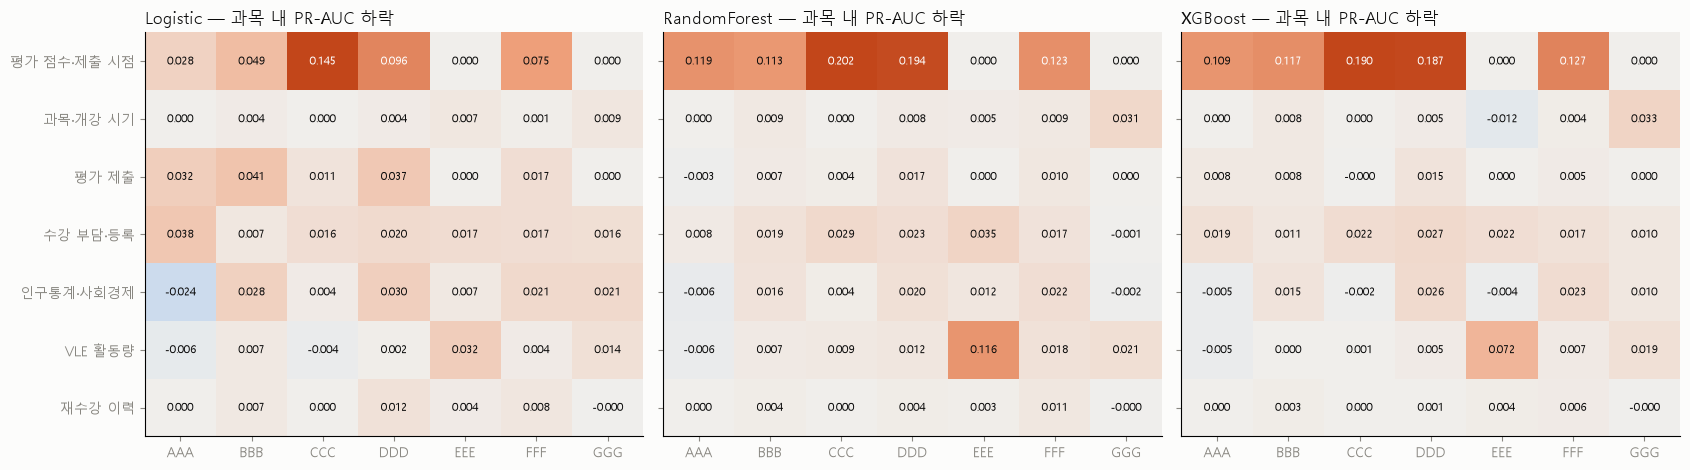

과목별 1위 묶음 (과목·개강 시기 제외)


,Logistic,RandomForest,XGBoost,세 모델 일치
module,,,,
AAA,수강 부담·등록,평가 점수·제출 시점,평가 점수·제출 시점,False
BBB,평가 점수·제출 시점,평가 점수·제출 시점,평가 점수·제출 시점,True
CCC,평가 점수·제출 시점,평가 점수·제출 시점,평가 점수·제출 시점,True
DDD,평가 점수·제출 시점,평가 점수·제출 시점,평가 점수·제출 시점,True
EEE,VLE 활동량,VLE 활동량,VLE 활동량,True
FFF,평가 점수·제출 시점,평가 점수·제출 시점,평가 점수·제출 시점,True
GGG,인구통계·사회경제,VLE 활동량,VLE 활동량,False


전체 PR-AUC 기준: 전역 섞기 vs 과목 안 섞기 (묶음)


전역 섞기                       과목 안 섞기                     
model       Logistic RandomForest XGBoost Logistic RandomForest XGBoost
unit                                                                   
평가 점수·제출 시점   0.0942       0.1467  0.1552   0.0848       0.1447  0.1448
과목·개강 시기      0.1050       0.0509  0.0437   0.0020       0.0053  0.0036
평가 제출         0.0230       0.0280  0.0374   0.0237       0.0078  0.0068
수강 부담·등록      0.0156       0.0203  0.0201   0.0153       0.0189  0.0179
인구통계·사회경제     0.0233       0.0117  0.0153   0.0194       0.0140  0.0139
VLE 활동량       0.0037       0.0166  0.0071   0.0028       0.0142  0.0070
재수강 이력        0.0072       0.0020  0.0008   0.0068       0.0029  0.0011

In [7]:
wm = agg[(agg.kind == 'group') & (agg.scope == 'within_module') & (agg.module != 'ALL')]
group_order = [g for g in g_imp.index]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
module_tables = {}
for ax, n in zip(axes, LEARNERS):
    piv = wm[wm.model == n].pivot(index='unit', columns='module', values='mean').reindex(index=group_order, columns=MODULES)
    module_tables[n] = piv
    vmax = np.nanmax(np.abs(piv.to_numpy()))
    ax.imshow(piv.to_numpy(dtype=float), cmap=DIV, vmin=-vmax, vmax=vmax, aspect='auto')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.iloc[i, j]
            ax.text(j, i, '' if pd.isna(v) else f'{v:.3f}', ha='center', va='center', fontsize=8,
                    color='#ffffff' if not pd.isna(v) and abs(v) > 0.6 * vmax else INK)
    ax.set_xticks(range(len(MODULES)), MODULES)
    ax.set_yticks(range(len(group_order)), group_order)
    ax.grid(False)
    ax.set_title(f'{n} — 과목 내 PR-AUC 하락', loc='left')
plt.tight_layout()
plt.show()

top_by_module = pd.DataFrame({n: module_tables[n].drop(index='과목·개강 시기').idxmax() for n in LEARNERS})
top_by_module['세 모델 일치'] = top_by_module.nunique(axis=1) == 1
print('과목별 1위 묶음 (과목·개강 시기 제외)')
display(top_by_module)
within_all = agg[(agg.kind == 'group') & (agg.scope == 'within_module') & (agg.module == 'ALL')].pivot(index='unit', columns='model', values='mean')[LEARNERS]
print('전체 PR-AUC 기준: 전역 섞기 vs 과목 안 섞기 (묶음)')
display(pd.concat({'전역 섞기': g_imp, '과목 안 섞기': within_all.reindex(g_imp.index)}, axis=1).round(4))

**해석**

- **평가가 있는 과목(BBB·CCC·DDD·FFF)은 세 모델 모두 "평가 점수·제출 시점"이 1위**다. 트리 모델 기준 과목 안 하락은 CCC 0.19–0.20, DDD 0.19로 가장 크다.
- **EEE는 세 모델 모두 "VLE 활동량"이 1위**다(RandomForest 0.116, XGBoost 0.072, Logistic 0.032). 25일 안에 평가가 없으면 **활동량이 사실상 유일한 행동 신호**다.
  → 개입 전략을 과목 구조에 따라 나눠야 한다는 정량 근거다.
- **GGG는 어떤 묶음도 크게 기여하지 못한다.** 가장 큰 값은 개강 시기(0.031–0.033)인데, GGG 이탈률이 학기마다 달랐기 때문이다(4.0% → 8.1%). VLE 활동량도 0.014–0.021에 그친다.
  25일 시점 정보로 GGG 학생을 구분하기 어렵다는 01의 결론을 재확인한다.
- **검증 역할**: EEE·GGG의 평가 묶음 하락이 0.000으로, 평가가 없는 과목에서 평가 피처가 쓰이지 않음을 확인했다.
- **수강 부담·등록 묶음은 모든 과목에서 0.01–0.04로 고르게 기여**한다. 과목과 무관한 공통 위험 신호다.
- AAA는 fold당 검증 행이 약 70명이라 Logistic만 1위가 다른 것(수강 부담·등록)은 해석하지 않는다.

## 6. 방향과 크기 — Logistic 오즈비

**방법**

- 01과 같은 전처리(중앙값 대치 + 결측 표시, `RobustScaler`, `drop='first'` 원-핫)로 만든 설계행렬에 **가중치 없는 로지스틱 회귀**(`statsmodels`)를 적합한다.
  01의 `class_weight='balanced'`는 절편을 옮길 뿐 기울기의 방향·상대 크기는 거의 같으므로, 오즈비 해석은 가중치 없는 적합이 정확하다.
- 같은 학생의 복수 수강을 반영해 **학생 단위 군집 강건 표준오차**로 95% 신뢰구간을 낸다.
- 수치형은 `RobustScaler` 단위, 즉 **"IQR(사분위 범위) 한 칸 증가"당 오즈비**다. IQR 값을 함께 표시한다. IQR이 0인 이진 변수(`no_vle_activity_25` 등)는 0 → 1 변화다.
- 범주형은 **기준 범주(알파벳·숫자 순 첫 범주) 대비** 오즈비다.

**주의**

- `avg_score_25`·`avg_submit_delay_25`는 제출자에게만 값이 있고 미제출자는 중앙값 + 결측 표시로 들어간다. 이 두 오즈비는 **"제출한 학생 안에서"**의 효과로 읽는다.
- 두 피처의 결측 표시는 7행만 다른 사실상 같은 변수라, 해석용 회귀에서는 `avg_score_25`의 결측 표시 하나만 남긴다. 이 표시는
  **"25일까지 점수가 없음(평가 기회 없음·이월·미제출)"** 여부다. 예측 모델(01)은 그대로이고, 오즈비 해석용 적합만 다르다.

두 결측 표시가 다른 행: 6


수렴: True | 의사 R²: 0.1137 | 조건수(설계행렬): 227


,피처,단위,오즈비,OR 하한,OR 상한,p값,유의(95%)
code_module_GGG,code_module,기준 범주 대비,0.171,0.106,0.275,0.0000,예
code_module_DDD,code_module,기준 범주 대비,2.150,1.534,3.014,0.0000,예
missingindicator_avg_score_25,avg_score_25,점수 없음 여부(0→1),2.001,1.430,2.801,0.0001,예
code_module_FFF,code_module,기준 범주 대비,1.964,1.397,2.762,0.0001,예
code_module_CCC,code_module,기준 범주 대비,1.816,1.274,2.589,0.0010,예
n_banked_25,n_banked_25,1 증가,0.552,0.373,0.818,0.0030,예
code_module_EEE,code_module,기준 범주 대비,0.569,0.360,0.900,0.0158,예
highest_education_No Formal quals,highest_education,기준 범주 대비,1.668,1.158,2.402,0.0060,예
n_submitted_25,n_submitted_25,1 증가,0.632,0.467,0.854,0.0028,예
disability_Y,disability,기준 범주 대비,1.556,1.376,1.759,0.0000,예


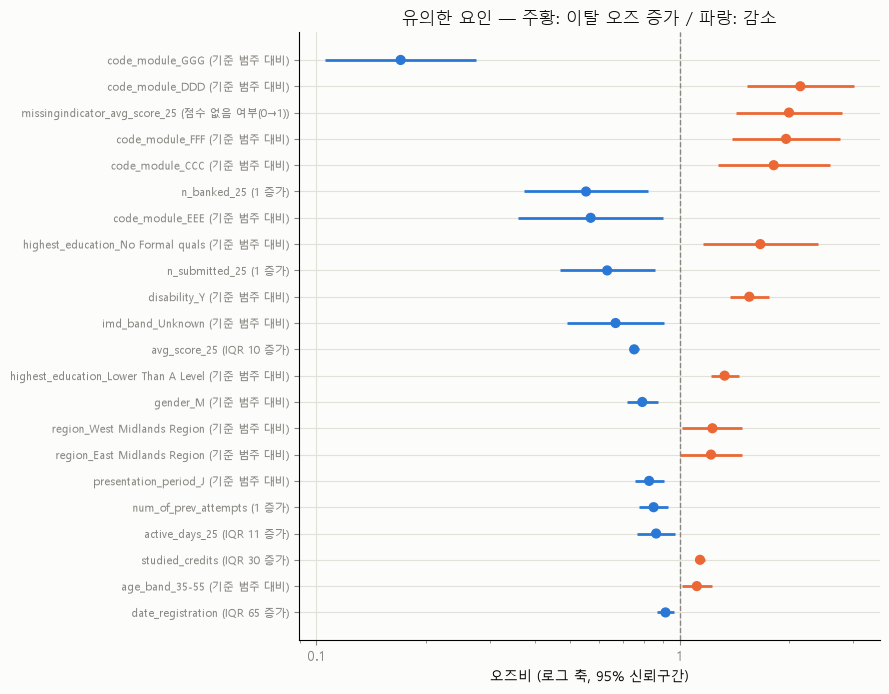

In [8]:
prep = make_pipeline('Logistic').named_steps['prep'].fit(X)
Xt = prep.transform(X)
Xt = Xt.toarray() if hasattr(Xt, 'toarray') else np.asarray(Xt)
names = [n.split('__', 1)[1] for n in prep.get_feature_names_out()]
design = pd.DataFrame(Xt, columns=names)
# avg_score_25 결측 표시와 avg_submit_delay_25 결측 표시는 7행만 다르다(점수만 없는 제출 7건).
# 둘을 함께 넣으면 서로 상쇄되는 큰 계수(OR 21.7 vs 0.085)가 나와 해석이 불가능하므로 해석용 회귀에서는 하나만 남긴다.
print('두 결측 표시가 다른 행:', int((design['missingindicator_avg_score_25'] != design['missingindicator_avg_submit_delay_25']).sum()))
design = design.drop(columns=['missingindicator_avg_submit_delay_25'])
logit = sm.Logit(y.to_numpy(), sm.add_constant(design, has_constant='add')).fit(
    disp=0, maxiter=500, cov_type='cluster', cov_kwds={'groups': pd.factorize(groups)[0]})
print('수렴:', logit.mle_retvals['converged'], '| 의사 R²:', round(logit.prsquared, 4), '| 조건수(설계행렬):', f'{np.linalg.cond(Xt):.0f}')

num_pipe = prep.named_transformers_['num']
scale = pd.Series(num_pipe.named_steps['scale'].scale_, index=[n for n in names if n in NUM or n.startswith('missingindicator_')])
ci = logit.conf_int()
coef = pd.DataFrame({'계수': logit.params, '하한': ci[0], '상한': ci[1], 'p값': logit.pvalues}).drop(index='const')
coef['오즈비'] = np.exp(coef['계수'])
coef['OR 하한'] = np.exp(coef['하한'])
coef['OR 상한'] = np.exp(coef['상한'])
coef['단위'] = [f'IQR {scale[n]:g} 증가' if n in NUM and scale[n] != 1 else ('1 증가' if n in NUM else ('점수 없음 여부(0→1)' if n.startswith('missingindicator_') else '기준 범주 대비')) for n in coef.index]


def raw_of(n):
    if n in NUM:
        return n
    if n.startswith('missingindicator_'):
        return n.replace('missingindicator_', '')
    return next(c for c in CAT if n.startswith(c + '_'))


coef['피처'] = [raw_of(n) for n in coef.index]
coef['유의(95%)'] = np.where((coef['OR 하한'] > 1) | (coef['OR 상한'] < 1), '예', '')
coef_view = coef.sort_values('계수', key=np.abs, ascending=False)
show(coef_view[['피처', '단위', '오즈비', 'OR 하한', 'OR 상한', 'p값', '유의(95%)']],
     {'오즈비': '{:.3f}', 'OR 하한': '{:.3f}', 'OR 상한': '{:.3f}', 'p값': '{:.4f}'})

sig = coef_view[coef_view['유의(95%)'] == '예'].head(22).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(sig))))
yy = np.arange(len(sig))
colors = np.where(sig['오즈비'] > 1, '#eb6834', '#2a78d6')
ax.hlines(yy, sig['OR 하한'], sig['OR 상한'], color=colors, lw=2)
ax.scatter(sig['오즈비'], yy, color=colors, s=40, zorder=3)
ax.axvline(1, color=MUTED, lw=1, ls='--')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks(yy, [f'{i} ({u})' for i, u in zip(sig.index, sig['단위'])], fontsize=8)
ax.set(xlabel='오즈비 (로그 축, 95% 신뢰구간)', title='유의한 요인 — 주황: 이탈 오즈 증가 / 파랑: 감소')
plt.tight_layout()
plt.show()

**해석** (다른 요인을 함께 통제한 조건부 효과, 학생 단위 군집 강건 95% 신뢰구간, 의사 R² 0.114)

| 요인 | 오즈비 [95% CI] | 읽는 법 |
|---|---|---|
| 점수 없음(기회 없음·이월·미제출) | **2.00** [1.43, 2.80] | 25일까지 점수가 없으면 이탈 오즈 2배 |
| 제출 1건 증가 | **0.63** [0.47, 0.85] | 기회 수가 같을 때 1건 더 내면 오즈 37% 감소 |
| 평가 점수 10점 증가(IQR) | **0.75** [0.73, 0.77] | 제출자 안에서 10점 높을수록 오즈 25% 감소 |
| 마감 대비 제출 1일 늦음 | **1.05** [1.03, 1.07] | 제출자 안에서 하루 늦을수록 오즈 5% 증가 |
| 수강 학점 30학점 증가(IQR) | **1.14** [1.10, 1.17] | 학점이 많을수록 위험 |
| 활동일 11일 증가(IQR) | **0.86** [0.76, 0.97] | 꾸준히 접속할수록 위험 감소 |
| 장애 있음 | **1.56** [1.38, 1.76] | |
| 최종 학력 Lower Than A Level / No Formal quals (A Level 기준) | **1.33** / **1.67** | |
| 남성 (여성 기준) | **0.79** [0.72, 0.87] | 과목 통제 시 남성 오즈가 21% 낮음 — **EDA 심슨의 역설과 일치**(전체로는 남성이 높음) |
| 재수강 1회 증가 / 이월 1개 증가 | 0.85 / 0.55 | 재수강생 중 이월받은 학생은 이탈이 낮음 |
| 등록이 65일 늦음(IQR) | 0.91 [0.87, 0.96] | 개강에 가깝게 등록할수록 위험 감소(7절 SHAP과 같은 방향) |
| J학기 (B학기 기준) | 0.82 | |
| 과목 (AAA 기준) | GGG 0.17, EEE 0.57 / DDD 2.15, FFF 1.96, CCC 1.82 | 과목 기준 이탈률 차이 |

- **유의하지 않은 요인**: 총 클릭 수, 자원 수, 무활동 플래그(활동일에 흡수됨), `n_opportunity_25`, IMD 대부분(Unknown만 0.67), 나이 55세 이상, 지역 대부분(West·East Midlands만 1.22–1.23으로 경계 유의).
- 오즈비는 **다른 요인이 같을 때의 연관**이며 인과 효과가 아니다. 예를 들어 "제출 1건 → 오즈 37% 감소"는 제출을 강제하면 이탈이 그만큼 줄어든다는 뜻이 아니다.

## 7. 영향의 모양 — XGBoost SHAP

**방법**: XGBoost 내장 TreeSHAP(`pred_contribs=True`)으로 개발 세트 전체로 학습한 모델의 **학생별 기여도(log-odds 단위)**를 구한다.
원-핫 열의 기여도는 원래 범주형 피처로 합친다.

- **평균 |SHAP|**: 예측에 평균적으로 얼마나 크게 관여하는가(학습 데이터 기준이라 permutation과 달리 "일반화 성능 기여"는 아니다).
- **방향**: 수치형 값과 SHAP의 순위 상관. 양수면 값이 클수록 이탈 위험을 올린다.
- **의존 그림**: 값에 따라 위험이 어떻게 변하는지 — 선형인지, 특정 구간에서 꺾이는지(개입 기준점 후보).

,평균 |SHAP|,방향(값↑ → 위험),순위 상관,SHAP 순위,permutation 순위(XGBoost)
avg_score_25,0.3677,감소,-0.97,1,1
n_opportunity_25,0.2137,증가,+0.67,2,2
code_module,0.2052,범주형,,3,3
avg_submit_delay_25,0.1352,증가,+0.93,4,5
studied_credits,0.1010,증가,+0.90,5,4
highest_education,0.0998,범주형,,6,10
presentation_period,0.0687,범주형,,7,7
active_days_25,0.0556,감소,-0.85,8,12
disability,0.0525,범주형,,9,6
date_registration,0.0510,감소,-0.87,10,8


SHAP 순위 vs permutation 순위 상관: 0.875


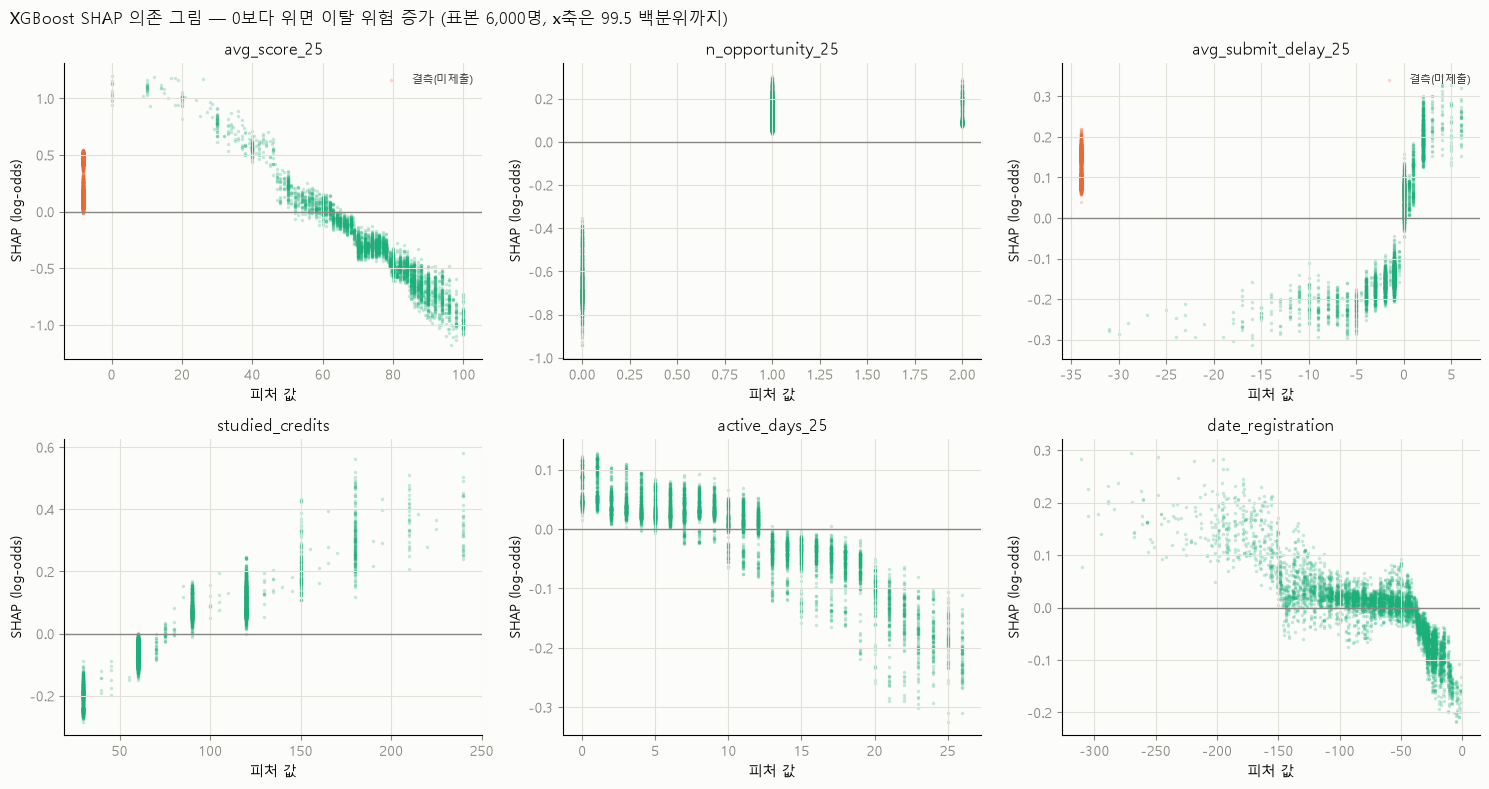

,피처,범주,평균 SHAP,행 수
0,code_module,GGG,-0.580,"1,721"
1,code_module,BBB,-0.224,"4,706"
2,code_module,AAA,-0.127,370
3,code_module,EEE,+0.013,"1,536"
4,code_module,CCC,+0.095,"1,520"
5,code_module,FFF,+0.148,"4,790"
6,code_module,DDD,+0.202,"3,861"
7,disability,N,-0.032,"16,724"
8,disability,Y,+0.249,"1,780"
9,highest_education,A Level or Equivalent,-0.096,"8,012"


In [9]:
xgb_full = make_pipeline('XGBoost').fit(X, y)
Xt_x = xgb_full.named_steps['prep'].transform(X)
contrib = xgb_full.named_steps['model'].get_booster().predict(xgboost.DMatrix(Xt_x, missing=np.nan), pred_contribs=True)
assert contrib.shape == (len(X), Xt_x.shape[1] + 1)
ohe = xgb_full.named_steps['prep'].named_transformers_['cat']
col_raw = NUM + [c for c, cats in zip(CAT, ohe.categories_) for _ in cats]
assert len(col_raw) == Xt_x.shape[1]
shap_raw = pd.DataFrame(contrib[:, :-1], columns=range(len(col_raw))).T.groupby(np.array(col_raw)).sum().T
shap_raw = shap_raw[FEATURES]
# 가법성 확인: 기여도 합 + 기준값 = 모델 log-odds
margin = xgb_full.named_steps['model'].get_booster().predict(xgboost.DMatrix(Xt_x, missing=np.nan), output_margin=True)
assert np.allclose(contrib.sum(axis=1), margin, atol=1e-3)

shap_tab = pd.DataFrame({'평균 |SHAP|': shap_raw.abs().mean()})
shap_tab['방향(값↑ → 위험)'] = [
    (lambda r: '증가' if r > 0.1 else ('감소' if r < -0.1 else '혼재'))(spearmanr(X[f], shap_raw[f], nan_policy='omit').statistic) if f in NUM else '범주형'
    for f in FEATURES]
shap_tab['순위 상관'] = [spearmanr(X[f], shap_raw[f], nan_policy='omit').statistic if f in NUM else np.nan for f in FEATURES]
shap_tab['SHAP 순위'] = shap_tab['평균 |SHAP|'].rank(ascending=False).astype(int)
shap_tab['permutation 순위(XGBoost)'] = f_rank['XGBoost']
shap_tab = shap_tab.sort_values('평균 |SHAP|', ascending=False)
show(shap_tab, {'평균 |SHAP|': '{:.4f}', '순위 상관': '{:+.2f}'})
print('SHAP 순위 vs permutation 순위 상관:', round(spearmanr(shap_tab['SHAP 순위'], shap_tab['permutation 순위(XGBoost)']).statistic, 3))

top_num = [f for f in shap_tab.index if f in NUM][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample = np.random.default_rng(RANDOM_STATE).choice(len(X), size=min(6000, len(X)), replace=False)
for ax, f in zip(axes.ravel(), top_num):
    xv, sv = X[f].to_numpy()[sample], shap_raw[f].to_numpy()[sample]
    nan = np.isnan(xv)
    hi = np.nanpercentile(xv, 99.5)
    keep = ~nan & (xv <= hi)
    ax.scatter(xv[keep], sv[keep], s=6, alpha=0.25, color='#1baf7a', linewidths=0)
    if nan.any():
        left = np.nanmin(xv) - 0.08 * (hi - np.nanmin(xv))
        ax.scatter(np.full(nan.sum(), left), sv[nan], s=6, alpha=0.25, color='#eb6834', linewidths=0, label='결측(미제출)')
        ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color=MUTED, lw=1)
    ax.set(title=f'{f}', xlabel='피처 값', ylabel='SHAP (log-odds)')
fig.suptitle('XGBoost SHAP 의존 그림 — 0보다 위면 이탈 위험 증가 (표본 6,000명, x축은 99.5 백분위까지)', x=0.01, ha='left', color=INK)
plt.tight_layout()
plt.show()

cat_rows = []
for f in ['code_module', 'disability', 'highest_education', 'imd_band', 'gender', 'age_band']:
    s = shap_raw[f].groupby(X[f]).mean().sort_values()
    for lvl, v in s.items():
        cat_rows.append({'피처': f, '범주': lvl, '평균 SHAP': v, '행 수': int((X[f] == lvl).sum())})
cat_shap = pd.DataFrame(cat_rows)
show(cat_shap, {'평균 SHAP': '{:+.3f}', '행 수': '{:,}'})

**해석**

- **SHAP 순위와 permutation 순위가 대체로 일치한다**(순위 상관 0.875).
  예외는 인구통계다. `highest_education`은 SHAP 6위지만 permutation 10위, `imd_band`는 12위 vs 20위다.
  SHAP은 학습 데이터에서 쓰인 정도이고 permutation은 새 데이터 예측에 기여한 정도라, **학습에서는 쓰지만 일반화에는 거의 기여하지 않는 성분**으로 보인다.
- **영향의 모양 (개입 기준점 후보)**

| 피처 | 모양 |
|---|---|
| `avg_score_25` | 약 55–60점을 경계로 그 아래는 위험 증가, 80점 이상은 크게 감소. **미제출(결측)은 40–50점대와 비슷한 위험** |
| `avg_submit_delay_25` | **마감일(0)에서 계단형으로 꺾인다.** 마감 후 제출은 위험 증가(+0.2 수준), 마감 5일 이상 전 제출은 감소(−0.2) |
| `n_opportunity_25` | 0이면 크게 감소(−0.6) — EEE·GGG 과목 구조 효과이지 행동이 아님 |
| `studied_credits` | 30학점 −0.2, 60학점 −0.05에서 **90학점부터 위험 증가로 전환**, 180학점 이상 +0.3 |
| `active_days_25` | 약 12일을 경계로 그 이상 접속하면 위험 감소 |
| `date_registration` | 개강 약 30일 전 이후 등록은 위험 감소, **150일 이상 일찍 등록한 학생은 위험 증가**(등록 후 동기 약화 가능성 — 가설) |

- **범주형**: 장애 있음 +0.25, 과목 GGG −0.58 / DDD +0.20, 학력 Lower Than A Level +0.12, IMD 20–30% +0.10. **성별은 ±0.02로 매우 작다.**

## 8. 개입 가능성 분류와 종합표

**왜 필요한가**: 중요한 요인이라도 **바꿀 수 없으면 개입 대상이 아니라 "누구를 지원할지" 식별하는 용도**다. P5 개입 전략은 개입 가능한 요인에서 출발한다.

| 분류 | 의미 | 피처 |
|---|---|---|
| 개입 가능 — 학습 활동 | 알림·안내로 25일 이후에도 바꿀 수 있는 행동 | VLE 활동량 4종 |
| 개입 가능 — 평가 제출 | 평가 전 알림·마감 안내로 바꿀 수 있는 행동 | `n_submitted_25`, `avg_submit_delay_25` |
| 부분 개입 — 학업 지원 | 튜터링 등으로 간접적으로 바꿀 수 있음 | `avg_score_25` |
| 부분 개입 — 수강 설계 | 다음 학기 수강 신청 상담으로 바꿀 수 있음(이번 학기엔 이미 결정) | `studied_credits` |
| 식별용 — 등록·이력 | 이미 일어난 사실. 지원 대상 식별에만 사용 | `date_registration`, `num_of_prev_attempts`, `n_banked_25` |
| 식별용 — 인구통계·사회경제 | 바꿀 수 없음. **공정성 검토 필요**(이 요인만으로 대상을 고르면 차별 소지) | `gender`, `region`, `highest_education`, `imd_band`, `age_band`, `disability` |
| 구조 — 과목·일정 | 학생이 아니라 과목 설계의 속성. 과목 운영 개선의 근거 | `code_module`, `presentation_period`, `n_opportunity_25` |

In [10]:
ACTION = {
    **{f: '개입 가능 — 학습 활동' for f in ['total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25']},
    'n_submitted_25': '개입 가능 — 평가 제출', 'avg_submit_delay_25': '개입 가능 — 평가 제출',
    'avg_score_25': '부분 개입 — 학업 지원', 'studied_credits': '부분 개입 — 수강 설계',
    **{f: '식별용 — 등록·이력' for f in ['date_registration', 'num_of_prev_attempts', 'n_banked_25']},
    **{f: '식별용 — 인구통계·사회경제' for f in ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']},
    **{f: '구조 — 과목·일정' for f in ['code_module', 'presentation_period', 'n_opportunity_25']},
}
assert set(ACTION) == set(FEATURES)


def or_direction(f):
    sub = coef[(coef['피처'] == f) & (coef['유의(95%)'] == '예')]
    if f in CAT:
        return f'유의 범주 {len(sub)}개' if len(sub) else '유의 범주 없음'
    main = coef.loc[f] if f in coef.index else None
    if main is None or main['유의(95%)'] != '예':
        return '유의하지 않음'
    return f"{'증가' if main['오즈비'] > 1 else '감소'} (OR {main['오즈비']:.2f}, {main['단위']})"


summary_table = pd.DataFrame({
    '개입 분류': pd.Series(ACTION),
    '묶음': pd.Series(FEATURE_GROUP),
    **{f'순위 {n}': f_rank[n] for n in LEARNERS},
    '평균 순위': f_rank.mean(axis=1),
    'PR-AUC 하락(평균)': f_imp.mean(axis=1),
    'SHAP 방향': shap_tab['방향(값↑ → 위험)'],
    'Logistic 오즈비': pd.Series({f: or_direction(f) for f in FEATURES}),
}).loc[FEATURES].sort_values('평균 순위')
show(summary_table, {'평균 순위': '{:.1f}', 'PR-AUC 하락(평균)': '{:.4f}'})

by_action = summary_table.groupby('개입 분류')['PR-AUC 하락(평균)'].sum().sort_values(ascending=False)
print('개입 분류별 개별 피처 하락 합 (겹치는 정보가 있어 묶음 하락과 다를 수 있음)')
display(by_action.round(4))

,개입 분류,묶음,순위 Logistic,순위 RandomForest,순위 XGBoost,평균 순위,PR-AUC 하락(평균),SHAP 방향,Logistic 오즈비
avg_score_25,부분 개입 — 학업 지원,평가 점수·제출 시점,1,1,1,1.0,0.1392,감소,"감소 (OR 0.75, IQR 10 증가)"
code_module,구조 — 과목·일정,과목·개강 시기,2,2,3,2.3,0.0597,범주형,유의 범주 5개
avg_submit_delay_25,개입 가능 — 평가 제출,평가 점수·제출 시점,3,5,5,4.3,0.0359,증가,"증가 (OR 1.05, 1 증가)"
studied_credits,부분 개입 — 수강 설계,수강 부담·등록,5,4,4,4.3,0.0145,증가,"증가 (OR 1.14, IQR 30 증가)"
n_opportunity_25,구조 — 과목·일정,평가 제출,9,3,2,4.7,0.0235,증가,유의하지 않음
disability,식별용 — 인구통계·사회경제,인구통계·사회경제,6,10,6,7.3,0.0074,범주형,유의 범주 1개
n_submitted_25,개입 가능 — 평가 제출,평가 제출,4,6,13,7.7,0.0120,감소,"감소 (OR 0.63, 1 증가)"
presentation_period,구조 — 과목·일정,과목·개강 시기,12,8,7,9.0,0.0043,범주형,유의 범주 1개
highest_education,식별용 — 인구통계·사회경제,인구통계·사회경제,7,11,10,9.3,0.0045,범주형,유의 범주 2개
gender,식별용 — 인구통계·사회경제,인구통계·사회경제,8,12,9,9.7,0.0034,범주형,유의 범주 1개


개입 분류별 개별 피처 하락 합 (겹치는 정보가 있어 묶음 하락과 다를 수 있음)


개입 분류
부분 개입 — 학업 지원      0.1392
구조 — 과목·일정         0.0875
개입 가능 — 평가 제출      0.0479
식별용 — 인구통계·사회경제    0.0162
부분 개입 — 수강 설계      0.0145
식별용 — 등록·이력        0.0067
개입 가능 — 학습 활동      0.0054
Name: PR-AUC 하락(평균), dtype: float64

**해석**

- **개입 가능·부분 개입 요인이 최상위에 있다.**

  | 순위(평균) | 요인 | 분류 | 개입 방향(가설) |
  |---:|---|---|---|
  | 1.0 | 25일 내 평가 점수 | 부분 개입 — 학업 지원 | 약 55점 미만 학생에게 학업 지원 |
  | 4.3 | 제출 시점 | 개입 가능 — 평가 제출 | 마감 전 알림 (마감 후 제출에서 위험이 꺾여 오름) |
  | 4.3 | 수강 학점 | 부분 개입 — 수강 설계 | 90학점 이상 과다 수강자 수강 상담 |
  | 7.7 | 제출 건수 | 개입 가능 — 평가 제출 | 25일 내 평가 미제출자 연락 |

- **VLE 학습 활동은 전역 순위가 12–18위로 낮다.** 평가 행동에 가려진 것이며, **평가가 없는 EEE에서는 1위 묶음**이다(5절).
  → 개입 전략도 "평가가 있는 과목은 제출·점수 중심, 평가가 없는 과목은 접속일 중심"으로 나누는 것이 정량 결과와 맞다.
- **구조 요인(`code_module`, `n_opportunity_25`, 개강 시기)이 상위권**이다. 학생 개입이 아니라 과목 운영 개선의 근거다
  (예: 25일 안에 평가가 없는 EEE·GGG에 조기 체크포인트 도입 검토).
- **식별용 인구통계 중에서는 장애 여부가 가장 크다**(평균 7.3위, 오즈비 1.56). 지원 서비스 연계 대상을 찾는 데는 쓸 수 있지만,
  **위험군 선정을 인구통계로만 하면 낙인·차별 우려**가 있어 행동 신호와 함께 써야 한다(P5 공정성 검토 항목).
- 위 개입 방향은 모두 **연관에서 나온 가설**이다. 실제 효과는 개입 실험(A/B)이나 인과 분석으로 확인해야 한다.

## 9. 최종 모델 결정 근거 정리

01의 성능·안정성 결과와 이 노트북의 해석 결과를 한 표로 모은다. **결정은 사용자 판단**이며, 이 표는 개발 세트 근거만 담는다.

In [11]:
decision = pd.DataFrame({
    'CV PR-AUC': {n: summary['cv']['pr_auc_mean'][n] for n in LEARNERS},
    '학기 단위 PR-AUC': {n: summary['cv']['term_split_pr_auc_mean'][n] for n in LEARNERS},
    '중요도 fold 간 안정성': consistency['fold 간 순위 상관 평균'],
    '다른 두 모델과 순위 상관(평균)': {n: rho.loc[n, [m for m in LEARNERS if m != n]].mean() for n in LEARNERS},
    '구조 의존도': consistency['구조 의존도(과목·개강 시기 비중)'],
    '과목 간 차이 의존도': consistency['과목 간 차이 의존도'],
    '행동 비중': consistency['행동 비중(VLE+평가 3묶음)'],
    '해석 수단': {'Logistic': '오즈비(직접)', 'RandomForest': 'permutation', 'XGBoost': 'permutation + SHAP(내장)'},
})
show(decision, {'CV PR-AUC': '{:.4f}', '학기 단위 PR-AUC': '{:.4f}', '중요도 fold 간 안정성': '{:.3f}',
                '다른 두 모델과 순위 상관(평균)': '{:.3f}', '구조 의존도': '{:.0%}', '과목 간 차이 의존도': '{:.0%}', '행동 비중': '{:.0%}'})

,CV PR-AUC,학기 단위 PR-AUC,중요도 fold 간 안정성,다른 두 모델과 순위 상관(평균),구조 의존도,과목 간 차이 의존도,행동 비중,해석 수단
Logistic,0.4004,0.3181,0.825,0.701,39%,43%,44%,오즈비(직접)
RandomForest,0.4061,0.3430,0.825,0.814,18%,26%,69%,permutation
XGBoost,0.4055,0.3604,0.840,0.801,16%,30%,71%,permutation + SHAP(내장)


**해석 — 최종 모델 결정에 주는 시사점**

1. **RandomForest와 XGBoost는 "무엇이 이탈을 가르는가"에 대한 답이 같다**(순위 상관 0.914, 공통 상위 요인). 둘 중 무엇을 골라도 P5 해석은 달라지지 않는다.
2. **Logistic은 예측 모델로는 불리하다.** 다른 모델과의 순위 일치가 가장 낮고(0.701), 과목 간 차이 의존도가 가장 높으며(43%), 01 학기 단위 성능도 최저(0.318)다.
   다만 **오즈비를 직접 해석할 수 있어 설명 보조 모델로는 가치**가 있다(6절, 심슨의 역설 확인).
3. **XGBoost vs RandomForest**

   | 기준 | RandomForest | XGBoost |
   |---|---|---|
   | CV PR-AUC | 0.4061 | 0.4055 (동점) |
   | 학기 단위 PR-AUC | 0.343 | **0.360** |
   | 중요도 fold 간 안정성 | 0.825 | **0.840** |
   | 과목 간 차이 의존도 | **26%** | 30% |
   | 행동 비중 | 69% | **71%** |
   | 해석 도구 | permutation | permutation + **SHAP(학생별 설명)** |

   해석 일관성은 동급이다. 학기 단위 성능과 학생별 설명(SHAP) 가능 여부에서 XGBoost가 앞서고, 과목 간 차이 의존도는 RandomForest가 조금 낮다.

→ 개발 세트 근거로는 **"예측 모델 XGBoost + 설명 보조 Logistic 오즈비"** 조합이 가장 설득력 있다. 결정은 사용자 판단이며, XGBoost로 바꾸면 holdout은 XGBoost로 한 번만 평가한다.

## 10. 결과 저장

| 파일 | 내용 |
|---|---|
| `feature_importance_permutation_n25.csv` | 모델 × (피처·묶음) × 범위(전역·과목 안) × 과목의 PR-AUC 하락 평균·표준편차 |
| `feature_importance_summary_n25.csv` | 피처별 개입 분류, 모델별 순위, SHAP 방향, 오즈비 요약 |
| `logistic_odds_ratios_n25.csv` | 설계행렬 열별 오즈비·95% 신뢰구간·p값 |
| `xgb_shap_importance_n25.csv` | 피처별 평균 \|SHAP\|, 방향, 순위 |

In [12]:
agg.to_csv(MODEL_DIR / 'feature_importance_permutation_n25.csv', index=False, encoding='utf-8-sig')
summary_table.rename_axis('feature').to_csv(MODEL_DIR / 'feature_importance_summary_n25.csv', encoding='utf-8-sig')
coef_view.rename_axis('column').to_csv(MODEL_DIR / 'logistic_odds_ratios_n25.csv', encoding='utf-8-sig')
shap_tab.rename_axis('feature').to_csv(MODEL_DIR / 'xgb_shap_importance_n25.csv', encoding='utf-8-sig')

chk = pd.read_csv(MODEL_DIR / 'feature_importance_summary_n25.csv')
assert len(chk) == len(FEATURES) and set(chk['feature']) == set(FEATURES)
for p in ['feature_importance_permutation_n25.csv', 'feature_importance_summary_n25.csv', 'logistic_odds_ratios_n25.csv', 'xgb_shap_importance_n25.csv']:
    print(f'CSV_files/모델링/{p}  ({(MODEL_DIR / p).stat().st_size / 1024:.1f} KB)')

CSV_files/모델링/feature_importance_permutation_n25.csv  (23.1 KB)
CSV_files/모델링/feature_importance_summary_n25.csv  (3.0 KB)
CSV_files/모델링/logistic_odds_ratios_n25.csv  (9.4 KB)
CSV_files/모델링/xgb_shap_importance_n25.csv  (1.1 KB)


## 11. 결론

### 이탈을 가르는 요인 (개발 세트, 세 모델 공통)

1. **25일 내 평가 행동이 가장 강한 신호다.** 점수(1위), 제출 시점(평균 4.3위), 제출 여부가 합쳐 트리 모델 중요도의 절반 이상을 차지한다.
   - 이 신호의 약 1/3은 "제출했는가", 약 2/3는 "점수 수준·제출 시점"이다.
   - 오즈비: 점수 없음 2.00배, 점수 10점당 0.75배, 마감 후 하루당 1.05배.
2. **과목 구조가 두 번째 신호다.** 과목별 기준 이탈률 차이(GGG 0.17배 ~ DDD 2.15배, AAA 기준)와 25일 내 평가 유무가 크게 작용한다. Logistic에서 특히 크다.
3. **수강 학점은 과목과 무관한 공통 위험 신호다.** 90학점부터 위험이 오르고, 30학점당 1.14배다.
4. **평가가 없는 과목(EEE)에서는 접속 활동이 핵심이다.** GGG는 25일 정보로 구분이 어렵다.
5. **인구통계 중에서는 장애 여부(1.56배)만 두드러진다.** 성별은 과목을 통제하면 방향이 뒤집히고 효과도 작다.

### 최종 모델 결정 근거 (9절)

- RandomForest와 XGBoost의 해석은 거의 같고, **XGBoost가 학기 단위 성능·해석 안정성·학생별 설명에서 앞선다.**
- Logistic은 과목 차이 의존도가 가장 높아 예측 모델로는 불리하지만, 오즈비 설명 보조로 유지할 가치가 있다.

### P5로 넘길 개입 가설 (인과 검증 전)

| 대상 | 개입 | 근거 |
|---|---|---|
| 25일 내 평가 미제출·마감 후 제출 | 마감 전 알림, 미제출자 연락 | 제출 여부 몫 약 1/3, 마감일 계단형 위험 |
| 25일 내 평가 약 55점 미만 | 학업 지원·튜터링 | 점수 SHAP 경계 |
| 90학점 이상 수강 | 수강 설계 상담(다음 학기) | 학점 SHAP 전환점 |
| 평가 없는 과목(EEE·GGG) | 접속일 기반 조기 연락, 과목 조기 체크포인트 검토 | EEE 과목 내 1위 = VLE 활동량 |

### 한계

- 중요도·오즈비는 **연관**이며 인과 효과가 아니다.
- 인구통계 요인은 지원 대상 식별에만 쓰고, 위험군 선정 기준으로 단독 사용하지 않는다(공정성).
- 모든 결과는 개발 세트 기준이며, holdout 기준 해석은 최종 모델 확정 후 필요한 경우에만 확인한다.

### 다음 단계

9절 근거로 최종 모델을 **XGBoost**로 정했다(2026-09-13). `03_Final_Model_Tiers.ipynb`에서 확률 보정과 관리자용 위험 등급 기준을 고정하고 holdout을 한 번 평가한다.
위 개입 가설은 `05_Intervention_Guide`의 위험 사유 코드·대응 가이드로 이어진다.